# Test case (DA FINIRE DI COMMENTARE)

Here is introduced a simple case where the MCMC method is used to estimate the input given the related output. An high fidelity (true) and a low fidelity structures are introduced. It is possible to notice the fact that th High Fidelity case is more precise that the Low Fidelity one

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
#from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
#from generalization import Neural_network, MultiFidelity

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform, beta
import arviz as az
import keras

Ray module not found. Multiprocessing features are not available


In [ ]:
# reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [2]:
highfid = lambda x: np.sin(x)+0.5*np.sin(2*x)+0.3*np.sin(3*x)
lowfid=lambda x:highfid(x)+0.2*np.sin(20*x)+0.1*np.sin(10*x)+0.1*np.sin(30*x)-0.4*np.sin(3*x)

x_test = np.linspace(0,5,1000)

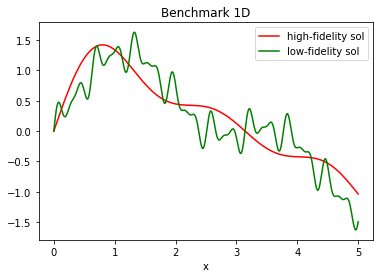

In [3]:
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

# Markov Chain Monte Carlo 

In [ ]:
dim=5
real_x = np.random.rand(dim)*5
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  

my_prior = multivariate_normal(mean_prior, cov_prior) # modo per settare uniforme?

sigma=0.1
cov_likelihood = sigma*np.eye(real_x.shape[0])

## High fidelity case

In [6]:

my_loglike = tda.GaussianLogLike(highfid(real_x)+np.random.normal(scale=sigma, size=dim), cov_likelihood)

my_posterior = tda.Posterior(my_prior, my_loglike, highfid)


In [7]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations =30000
    burnin = 5000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=3, force_sequential=True)

Sampling chain 1/3


Running chain, α = 0.83:   0%|          | 38/30000 [00:00<01:20, 374.47it/s]

Running chain, α = 0.37:  16%|█▌        | 4657/30000 [00:16<01:28, 287.05it/s]


KeyboardInterrupt: 

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.631  0.555   0.739    2.770      0.027    0.019     462.0    1275.0   
x1  3.454  0.440   2.669    4.410      0.018    0.013     704.0     436.0   
x2  2.856  0.523   1.810    3.705      0.023    0.016     524.0     849.0   
x3  2.470  0.460   1.626    3.249      0.018    0.013     667.0    1493.0   
x4  2.431  0.463   1.581    3.251      0.019    0.013     605.0    1752.0   

    r_hat  
x0   1.01  
x1   1.00  
x2   1.00  
x3   1.01  
x4   1.01  
[1.16640038 3.95822015 3.11255066 2.6959937  2.76251441]


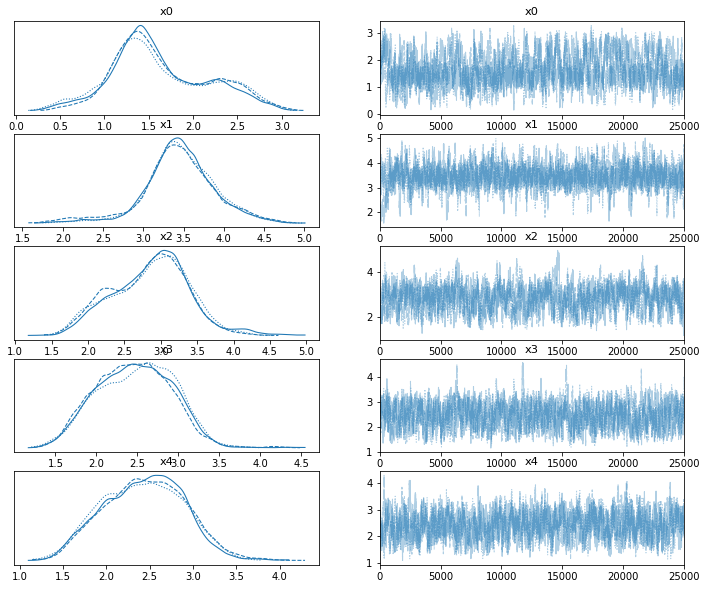

In [ ]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


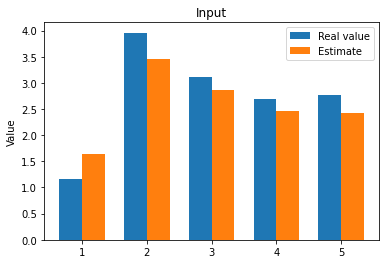

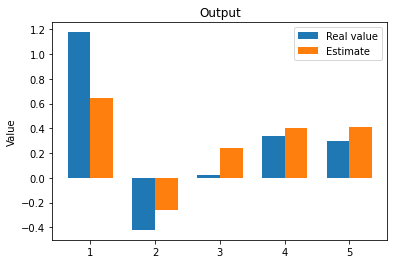

In [61]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


## Low Fideilty case

In [63]:


my_loglike = tda.GaussianLogLike(highfid(real_x)+np.random.normal(scale=sigma, size=dim), cov_likelihood)

my_posterior = tda.Posterior(my_prior, my_loglike, lowfid)


In [64]:
rwmh_cov = np.eye(len(real_x))
rmwh_scaling = 0.1
rwmh_adaptive = False
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations =30000
    burnin = 5000
    
my_chains = tda.sample(my_posterior, my_proposal, iterations=iterations, n_chains=3, force_sequential=True)

Sampling chain 1/3


Running chain, α = 0.11: 100%|██████████| 30000/30000 [01:40<00:00, 297.09it/s]


Sampling chain 2/3


Running chain, α = 0.24: 100%|██████████| 30000/30000 [01:34<00:00, 316.15it/s]


Sampling chain 3/3


Running chain, α = 0.13: 100%|██████████| 30000/30000 [01:36<00:00, 309.42it/s]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.450  0.320   0.890    2.017      0.017    0.012     386.0     788.0   
x1  2.612  0.509   1.758    3.526      0.041    0.029     166.0     320.0   
x2  3.223  0.717   2.366    4.489      0.228    0.166      13.0     135.0   
x3  3.101  0.644   2.378    4.380      0.180    0.130      17.0     174.0   
x4  2.569  0.505   1.751    3.484      0.049    0.035     117.0     274.0   

    r_hat  
x0   1.02  
x1   1.01  
x2   1.17  
x3   1.13  
x4   1.02  
[0.95957633 2.778512   4.74251174 4.89215397 2.65123929]


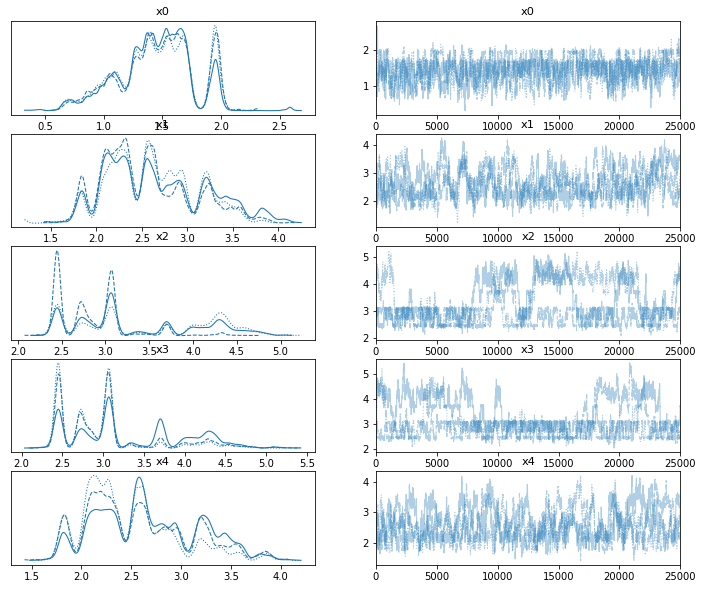

In [65]:
idata = tda.to_inference_data(my_chains, burnin=burnin)
print(az.summary(idata))
print(real_x)
az.plot_trace(idata)
plt.show()


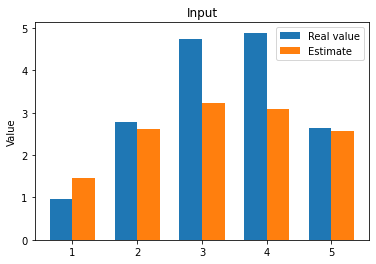

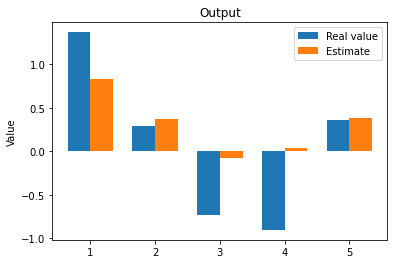

In [66]:

values2=np.array(az.summary(idata)['mean'])
values1=real_x
values = np.vstack((values1, values2))

# Creare categorie in base alla lunghezza di values
categories = np.arange(1, values.shape[1] + 1)

# Larghezza delle colonne
bar_width = 0.35

# Posizioni delle colonne
bar_positions = [categories - bar_width/2 + i*bar_width for i in range(values.shape[0])]

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Input')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()


values2 = highfid(values2)
values1=highfid(values1)

values = np.vstack((values1, values2))

# Creazione del plot
for i in range(values.shape[0]):
    plt.bar(bar_positions[i], values[i, :], width=bar_width)


plt.ylabel('Value')
plt.title('Output')
plt.xticks(categories)
plt.legend(["Real value", "Estimate"])


# Mostra il plot
plt.show()
